<a href="https://colab.research.google.com/github/iratuh/UndergraduateThesis_Nowcasting/blob/main/Scraping_Google_Trends.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# install packages
!pip install pytrends

In [ ]:
# Import library
import numpy as np
import pandas as pd
import time
import random
import math
from datetime import datetime, timedelta
from pytrends.request import TrendReq
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Scraping

Domain area: Jakarta (Jakarta, Banten, Jawa Barat).

Popular areas that are frequently visited as tourist attractions:
* Jawa Barat ⇒ Bogor (Puncak), Bandung, Garut (Kawah Papandayan), Sukabumi (Pelabuhan Ratu)
* DKI Jakarta ⇒ Kota Tua, Ancol, TMII, Pulau Seribu, Blok M, Monas
* Banten ⇒ Pangandaran, Anyer, Tanjung Lesung

Related aspects with Google Trends: hotel accomocation, air transportation booking, sea transportation booking, land transportation booking (train, bus, private vehicle), food purchases and shopping venues, tourist attraction tickets.

Safety limit: 50 keywords
Size per request: 5 keywords
50 keywords => all keywords that want to be used.

Anchor: "Tempat wisata Jakarta"

Reason: stable and neutral, universal to its all aspects, represents tourism intent.

We used anchor and scaling for normalization due to Google Trends characteristic which the number itself shows 0-100 relative to its maximum popular point of the keywords.

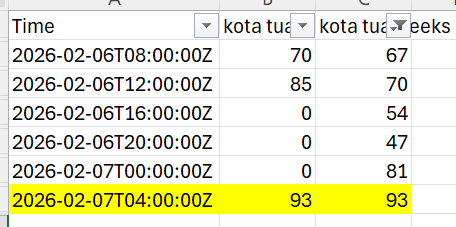

Basically, number of trends that has been extracted will be different in a request for past 24 hours (data lag is per 16 mins) will be different with a request for past week (data lag is per 4 hours).

**WHY?**
=> for one independent query request, the number of google trends index that will be show is the number of popularity relatives to its peak popularity in that 'requested' period of time. In this case of above picture, the first period of time is by the past 24 hours (lag by 16 minutes) and the right one is by the past one week (lag by 4 hours). Because of its difference of requested period of time, the number og google trends index will be different too.

Therefore, the formula of google trends index is:
> (x)/max[(x)]
where (x) is the query in a given period of time

## Scraping Strategy

Commonly Google Trends can not display daily data if the time frame is > 240 days. If the requested time frame data > 240, it will only show monthly lag data which we are not interested in. So in here we use window strategy to keep the requested time frame data consistent in daily lag.

Another challenge we have is the maximum batch requested. We will not perform the independent query request google trend data which only consist of one query in a time. We will use the multiple query request data, which will be normalized with the anchor that we use. So in a one batch request, it consists of 4 different keywords + 1 anchor. To normalize the relativity in its batch request (since in one request we will perform different keywords), we use scaling ratio. So the data itself will be multiply by the scaling ratio of each batch.  

In [ ]:
# -------- CONFIG ----------
KEYWORDS = [
    #Anchor
    'wisata jakarta',

    #general search term
    'tempat wisata jakarta',
    'liburan ke jakarta',

    # Hotel accommodation
    'hotel jakarta',
    'hotel murah jakarta',
    'penginapan jakarta',
    'booking hotel jakarta',
    'staycation jakarta',

    # Air transportation
    'tiket pesawat ke jakarta',
    'harga tiket pesawat ke jakarta',
    'penerbangan ke jakarta',
    'bandara soekarno hatta',
    'jadwal penerbangan jakarta',

    # Land transportation
    'tiket kereta ke jakarta',
    'kereta ke jakarta',
    'jadwal kereta ke jakarta',
    'bus ke jakarta',
    'travel ke jakarta',
    'tol menuju jakarta',

    # Sea transportation
    'kapal ke jakarta',
    'pelabuhan muara angke',
    'wisata pulau seribu',

    # Consumption and shopping
    'kuliner jakarta',
    'tempat makan jakarta',
    'cafe jakarta',
    'mall jakarta',
    'event jakarta',
    'blok m',
    'grand indonesia',

    # Tourist attractions
    'ancol jakarta',
    'monas',
    'tmii',
    'kota tua jakarta',
    'dunia fantasi',
    'ragunan',
    'pulau seribu'
]

START_DATE = "2010-01-01"
END_DATE   = "2025-07-31"
GEO = "ID"          # wilayah: Indonesia
HL = "id"           # bahasa
TZ = 420            # GMT+7 -> 420
BATCH_SIZE_OTHER = 4  # besides anchor, max 4 more -> total 5 per request
SLEEP_MIN = 5
SLEEP_MAX = 12
RETRY_LIMIT = 3
# If timeframe > DAILY_WINDOW_DAYS, we'll split timeline to keep daily resolution.
# Google tends to return weekly if timeframe too long; safe window <= 240 days.
DAILY_WINDOW_DAYS = 240
WINDOW_OVERLAP_DAYS = 7   # overlap between windows to compute scaling

To overcome the API block limit request, we split the keywords per batch (max 5 keywords) and use time sleep.

In [ ]:
# --------- helper funcs ----------
def daterange_windows(start_dt, end_dt, window_days=DAILY_WINDOW_DAYS, overlap_days=WINDOW_OVERLAP_DAYS):
    """Generate (window_start, window_end) with overlap to allow stitching/scaling."""
    start = start_dt
    while start < end_dt:
        end = start + timedelta(days=window_days)
        if end > end_dt:
            end = end_dt
        yield start, end
        # next window starts window_days - overlap_days ahead of current start
        start = start + timedelta(days=window_days - overlap_days)

def safe_sleep():
    time.sleep(random.uniform(SLEEP_MIN, SLEEP_MAX))

def build_with_retry(pytrends, kw_list, timeframe, geo, retries=RETRY_LIMIT):
    last_exc = None
    for attempt in range(1, retries+1):
        try:
            pytrends.build_payload(kw_list=kw_list, timeframe=timeframe, geo=geo)
            df = pytrends.interest_over_time()
            return df
        except Exception as e:
            last_exc = e
            wait = 2 ** attempt
            print(f"[WARN] build_payload failed (attempt {attempt}/{retries}): {e}. Retrying in {wait}s...")
            time.sleep(wait)
    raise last_exc

In [ ]:
# -------- main logic ----------
def scrape_trends(keywords, start_date, end_date):
    # basic validation
    if len(keywords) == 0:
        raise ValueError("Masukkan minimal 1 keyword.")
    if len(keywords) > 50:
        print("[WARN] Kamu memasukkan >50 kata. Ini mungkin butuh batching tambahan. Skrip dioptimalkan untuk ~10 kata.")

    pytrends = TrendReq(hl=HL, tz=TZ)  # add proxies=[...] jika perlu

    start_dt = datetime.strptime(start_date, "%Y-%m-%d")
    end_dt   = datetime.strptime(end_date, "%Y-%m-%d")

    anchor = keywords[0]
    others = keywords[1:]

    final_df = pd.DataFrame()

    # decide whether to use windows to preserve daily granularity
    total_days = (end_dt - start_dt).days
    if total_days <= DAILY_WINDOW_DAYS:
        windows = [(start_dt, end_dt)]
    else:
        windows = list(daterange_windows(start_dt, end_dt, DAILY_WINDOW_DAYS, WINDOW_OVERLAP_DAYS))
        print(f"[INFO] Rentang {total_days} hari > {DAILY_WINDOW_DAYS}. Membagi jadi {len(windows)} window(s).")

    # process each time window
    for w_i, (w_start, w_end) in enumerate(windows, start=1):
        timeframe = f"{w_start.strftime('%Y-%m-%d')} {w_end.strftime('%Y-%m-%d')}"
        print(f"\n[WINDOW {w_i}/{len(windows)}] {timeframe}")

        # build batches: each batch includes anchor + up to BATCH_SIZE_OTHER other keywords
        window_dfs = []
        for i in range(0, len(others), BATCH_SIZE_OTHER):
            batch_others = others[i:i+BATCH_SIZE_OTHER]
            batch = [anchor] + batch_others
            print(f"  - Batch keywords: {batch}")

            df = build_with_retry(pytrends, batch, timeframe, GEO)
            if df is None or df.empty:
                print(f"    [WARN] Empty result for batch {batch}. Skipping.")
                safe_sleep()
                continue

            # drop isPartial when present
            if 'isPartial' in df.columns:
                df = df.drop(columns=['isPartial'])

            # ensure index is datetime and sorted
            df.index = pd.to_datetime(df.index)
            df = df.sort_index()

            window_dfs.append(df)
            safe_sleep()

        if len(window_dfs) == 0:
            print(f"  [ERROR] Tidak ada data untuk window {timeframe}. Lanjutkan window berikutnya.")
            continue

        # Merge batches within this window, scaling by anchor to match first batch
        base_df = window_dfs[0].copy()
        # subsequent batches: compute scaling factor vs base_df using anchor column
        for k in range(1, len(window_dfs)):
            df_k = window_dfs[k].copy()
            # find common dates
            common_idx = base_df.index.intersection(df_k.index)
            if len(common_idx) == 0:
                # no overlap (weird), fallback to max-based ratio
                print("    [WARN] tidak ada tanggal overlap antar-batch! Melakukan fallback scaling.")
                a_ref = base_df[anchor].max() if anchor in base_df.columns else None
                a_k   = df_k[anchor].max() if anchor in df_k.columns else None
                if a_k is None or a_k == 0:
                    ratio = 1.0
                else:
                    ratio = (a_ref / a_k) if a_ref is not None else 1.0
            else:
                mask = (base_df.loc[common_idx, anchor] > 0) & (df_k.loc[common_idx, anchor] > 0)
                if mask.sum() >= 3:
                    ratios = (base_df.loc[common_idx, anchor][mask] / df_k.loc[common_idx, anchor][mask])
                    ratio = float(ratios.median())
                else:
                    # fallback to ratio of maxima where possible
                    a_ref = base_df[anchor].max() if anchor in base_df.columns else None
                    a_k   = df_k[anchor].max() if anchor in df_k.columns else None
                    if a_k is None or a_k == 0:
                        ratio = 1.0
                    else:
                        ratio = (a_ref / a_k) if a_ref is not None else 1.0

            print(f"    scaling batch {k+1}/{len(window_dfs)} by ratio {ratio:.4f}")
            # apply scaling to all numeric columns of df_k
            df_k_scaled = df_k.copy() * ratio
            # merge into base_df (keep anchor from base_df)
            for col in df_k_scaled.columns:
                if col == anchor:
                    continue
                if col in base_df.columns:
                    # if column exists, fill missing dates then skip duplicates
                    base_df[col] = base_df[col].combine_first(df_k_scaled[col])
                else:
                    base_df = base_df.join(df_k_scaled[[col]], how='outer')

        # now base_df has all keywords for this window
        window_df = base_df

        # Stitch window_df to final_df: scale window to match final_df anchor on overlap if final_df not empty
        if final_df.empty:
            final_df = window_df.copy()
        else:
            # compute overlap with existing final_df
            overlap_idx = final_df.index.intersection(window_df.index)
            if len(overlap_idx) > 0:
                mask = (final_df.loc[overlap_idx, anchor] > 0) & (window_df.loc[overlap_idx, anchor] > 0)
                if mask.sum() >= 3:
                    ratio = float((final_df.loc[overlap_idx, anchor][mask] / window_df.loc[overlap_idx, anchor][mask]).median())
                else:
                    a_ref = final_df[anchor].max() if anchor in final_df.columns else None
                    a_w   = window_df[anchor].max() if anchor in window_df.columns else None
                    if a_w is None or a_w == 0:
                        ratio = 1.0
                    else:
                        ratio = (a_ref / a_w) if a_ref is not None else 1.0
                print(f"  [STITCH] scaling window by {ratio:.4f} before appending")
            else:
                print("  [STITCH] no overlap with final_df; appending without overlap-scaling fallback")
                a_ref = final_df[anchor].max() if anchor in final_df.columns else None
                a_w   = window_df[anchor].max() if anchor in window_df.columns else None
                if a_w is None or a_w == 0:
                    ratio = 1.0
                else:
                    ratio = (a_ref / a_w) if a_ref is not None else 1.0

            window_df = window_df * ratio
            # append only new dates (avoid duplicates)
            to_add_idx = window_df.index.difference(final_df.index)
            if len(to_add_idx) > 0:
                final_df = pd.concat([final_df, window_df.loc[to_add_idx]], axis=0)
            else:
                print("  [STITCH] tidak ada tanggal baru dari window ini setelah scalingu; skip append.")

    # final tidy: sort by date and round
    final_df = final_df.sort_index()
    final_df = final_df.fillna(0)
    # optionally round
    final_df = final_df.round(2)
    return final_df

In [ ]:
# ----- RUN -----
if __name__ == "__main__":
    df = scrape_trends(KEYWORDS, START_DATE, END_DATE)
    print("\nSelesai. Contoh data:")
    print(df.head())
    # Simpan
    df.to_csv("gt_final.csv", encoding="utf-8-sig")
    print("Data tersimpan:gt_final.csv")

[INFO] Rentang 5690 hari > 240. Membagi jadi 25 window(s).

[WINDOW 1/25] 2010-01-01 2010-08-29
  - Batch keywords: ['wisata jakarta', 'tempat wisata jakarta', 'liburan ke jakarta', 'hotel jakarta', 'hotel murah jakarta']
  - Batch keywords: ['wisata jakarta', 'penginapan jakarta', 'booking hotel jakarta', 'staycation jakarta', 'tiket pesawat ke jakarta']


KeyboardInterrupt: 